데이터 로드

데이터 출처 링크 : https://github.com/bab2min/corpus/tree/master/sentiment

In [1]:
import re   # 정규표현식
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import urllib.request
from collections import Counter
from sklearn.model_selection import train_test_split

In [2]:
# 전체 데이터에 해당하는 naver_shopping.txt 다운로드 하기
urllib.request.urlretrieve("https://raw.githubusercontent.com/ukairia777/tensorflow-nlp-tutorial/main/10.%20RNN%20Text%20Classification/dataset/naver_shopping.txt", filename="naver_shopping.txt")

('naver_shopping.txt', <http.client.HTTPMessage at 0x7e8d33794430>)

In [3]:
pd.read_table('naver_shopping.txt')

,5,배공빠르고 굿
0,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
1,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
2,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
3,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
4,2,비추합니다 계란 뒤집을 때 완전 불편해요 ㅠㅠ 코팅도 묻어나고 보기엔 예쁘고 실용적...
...,...,...
199994,2,장마라그런가!!! 달지않아요
199995,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199996,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199997,5,넘이쁘고 쎄련되보이네요~


In [8]:
total_data = pd.read_table('naver_shopping.txt', names=['ratings', 'reviews'])
# 열 제목 생성('ratings', 'reviews')
total_data[:5]

,ratings,reviews
0,5,배공빠르고 굿
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ


In [9]:
print('전체 리뷰 개수: ', len(total_data))

전체 리뷰 개수:  200000


In [11]:
total_data['ratings'].value_counts()

ratings
5    81177
2    63989
1    36048
4    18786
Name: count, dtype: int64

훈련용 데이터와 테스트데이터 분리

In [13]:
condition = (total_data.ratings > 3)
total_data[condition]

,ratings,reviews
0,5,배공빠르고 굿
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ
10,5,사이즈도 딱이고 귀엽고 넘 좋아요 ㅎㅎ
14,5,촉감도 좋고 무게감이나 핏도 편합니다
...,...,...
199994,4,전반적으로 어플이나 각종 IOT서비스와의 완성도는 좋음 그러나 서버의 잦은 다운과 ...
199996,5,다이슨 케이스 구매했어요 다이슨 슈퍼소닉 드라이기 케이스 구매했어요가격 괜찮고 배송...
199997,5,로드샾에서 사는것보다 세배 저렴하네요 ㅜㅜ 자주이용할께요
199998,5,넘이쁘고 쎄련되보이네요~


In [12]:
# 긍정 (평점이 4점, 5점 >> 1, 평점이 1점, 2점 >> 0)

np.select([total_data.ratings > 3], [1], default=0)
# np.select(condition, choice, default=0)
# >> condition 조건이 참(True= 1) choice, 그렇지 않으면 0

array([1, 0, 1, ..., 1, 1, 1])

In [14]:
total_data['label'] = np.select([total_data.ratings > 3], [1], default=0)
total_data[:5]

,ratings,reviews,label
0,5,배공빠르고 굿,1
1,2,택배가 엉망이네용 저희집 밑에층에 말도없이 놔두고가고,0
2,5,아주좋아요 바지 정말 좋아서2개 더 구매했어요 이가격에 대박입니다. 바느질이 조금 ...,1
3,2,선물용으로 빨리 받아서 전달했어야 하는 상품이었는데 머그컵만 와서 당황했습니다. 전...,0
4,5,민트색상 예뻐요. 옆 손잡이는 거는 용도로도 사용되네요 ㅎㅎ,1


In [16]:
# 각 열에 대해서 중복 제외 샘플 카운팅 하기

total_data['ratings'].nunique() # nunique() : number of uniquesness
# >> 1,2,4,5

4

In [17]:
total_data['reviews'].nunique()

199908

In [19]:
total_data['label'].nunique()

2

In [20]:
total_data.drop_duplicates(subset=['reviews'], inplace=True)
# in place of ~ : ~을 대신하다
# 'reviews' 열에서 중복인 내용 >> 중복 제거

In [21]:
print('총 샘플 수: ', len(total_data))

총 샘플 수:  199908


In [22]:
# 결측치 확인
total_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199908 entries, 0 to 199999
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   ratings  199908 non-null  int64 
 1   reviews  199908 non-null  object
 2   label    199908 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 6.1+ MB


In [24]:
total_data.isnull().sum()

ratings    0
reviews    0
label      0
dtype: int64

In [26]:
total_data.isnull().values.any()

False

In [27]:
# 훈련용 데이터 : 테스트 데이터 = 3 : 1

train_data, test_data =\
train_test_split(total_data, test_size=0.25, random_state=42 )
# random_state=42 무작위, 임의로 섞은 샘플 중 하나(42번째) 분석에 사용하겠다는 의미

In [28]:
print('훈련용 리뷰의 개수: ', len(train_data))
print('테스트용 리뷰의 개수: ', len(test_data))

훈련용 리뷰의 개수:  149931
테스트용 리뷰의 개수:  49977


In [29]:
# 모델링 (train_data)

train_data.head()

,ratings,reviews,label
59666,2,사이즈를 3센치씩 늘린건데도 작아요 그리고 색상은 완전 달라요 칙칙한핑크네요ㅠㅠ 많...,0
12433,2,ㅂ불만족.. 빗이 아픔 .. 멍이피부에 빗질못해주겟네요,0
146516,1,이 제품쓰고 삼일만에 변기물이 잘 안내려갔어요. 혹시나해서 다시 빼보니 물이 다시 ...,0
158109,5,적당하고 만족합니다,1
70219,2,편하자고 이용하는 밀키튼데 손 은근 많이 가서 저는 패쓰요,0


In [31]:
# EDA (탐색적 데이터 분석)

train_data['label'].value_counts()

label
1    75013
0    74918
Name: count, dtype: int64

<Axes: xlabel='label'>

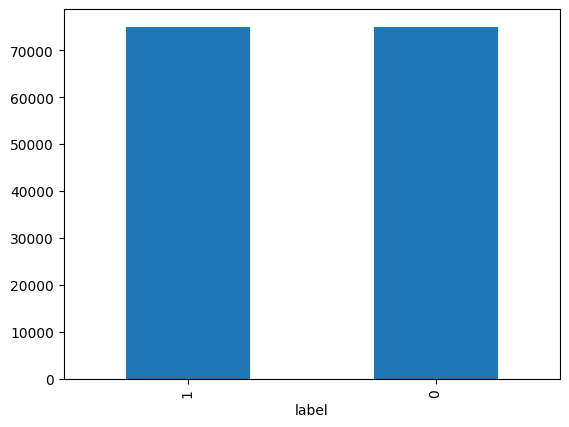

In [32]:
train_data['label'].value_counts().plot(kind='bar')

In [33]:
train_data.groupby('label').size()

label
0    74918
1    75013
dtype: int64

In [34]:
train_data.groupby('label').size().reset_index(name='count')

,label,count
0,0,74918
1,1,75013


실전 모델링_감성분석

In [35]:
!pip install transformers

In [36]:
# https://huggingface.co/
# https://huggingface.co/matthewburke/korean_sentiment


from transformers import pipeline
classifier = pipeline("text-classification", model="matthewburke/korean_sentiment")
custom_tweet = "영화 재밌다."
preds = classifier(custom_tweet, return_all_scores=True)
is_positive = preds[0][1]['score'] > 0.5


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/396k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/788k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [37]:
print('긍정 여부:', is_positive)

긍정 여부: True


In [38]:
print('스코어 점수 확인: ', preds[0][1]['score'])

스코어 점수 확인:  0.9731518626213074


In [39]:
# 평가용 데이터 (test_data)

test_data.head(3)

,ratings,reviews,label
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0
125080,1,피부에 뾰루지가 많이 올라와요,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1


In [40]:
def pred_sentiment(text):
    preds = classifier(text, return_all_scores=True)
    if preds[0][1]['score'] > 0.5:
        return 1
    else:
        return 0

In [41]:
 pred_sentiment('피부에 뾰루지가 많이 올라와요	')

/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


0

In [42]:
from tqdm import tqdm
tqdm.pandas()

In [43]:
# test_data 상위 1,000개만 복사
test_data.value_counts()

ratings  reviews                                                                            label
1         남자 봄 7부 블랙 레터링 오버핏 반팔 박스 후드티  라고 적혀있어서 구매한건데 FEMININE 이라고 적혀있네요. 오버로크 뜯어서 쓰겠습니다.  0        1
5        도라지가 많이 들어서 좋아요                                                                    1        1
         덕분에 올 겨울 잘 보냈습니다.^^                                                                1        1
         덕분에 인사잘드렸습니다                                                                       1        1
         덕분에 잘칠했습니다.                                                                        1        1
                                                                                                    ..
2        상태가 안좋게 오고 조립하기 힘드네요                                                               0        1
         상태가 안좋아요                                                                           0        1
         상태가 엉망입니다.                                                           

In [44]:
test_data_sample = test_data[:1000].copy()

In [45]:
test_data_sample

,ratings,reviews,label
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0
125080,1,피부에 뾰루지가 많이 올라와요,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1
72927,5,재구매입니다. 핏도 좋고 착용감도 좋습니다.,1
83890,1,파손제품 온거 출장같다 오늘 받았는데 현재상황 장난하시는지 택배회사 항의하세요,0
...,...,...,...
148745,4,좋아요 딱 맞아요 배송 일주일,1
138045,5,빨간색 검은색 샀어요 있는 것만으로도 든든하네요 잘 쓸께요,1
160462,5,설치 꼼꼼하게 잘해주셨고~ 저렴한 가격에 잘 설치했어요,1
24513,5,마블 구매했다가 품절이라 그레이로 변경했는데 그레이도 넘 이쁘네여~! 가격도 저렴하...,1


In [47]:
test_data_sample['pred'] = test_data_sample['reviews'].progress_apply(pred_sentiment)
# progress_apply(pred_sentiment) : tqdm 제공하는 pred_sentiment 함수에 reviews 데이터를 적용하는 과정을 보여줌

  0%|          | 0/1000 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(
100%|██████████| 1000/1000 [02:22<00:00,  7.00it/s]


In [48]:
test_data_sample

,ratings,reviews,label,pred
193242,1,너무 낮고 솜도 적고 실망스럽습니다,0,0
125080,1,피부에 뾰루지가 많이 올라와요,0,0
122750,5,배송도 빠르네요 가격대비 좋은것 같아요~~~ 첨에는 힘들어하나 조금 지나니 잘 하네요,1,1
72927,5,재구매입니다. 핏도 좋고 착용감도 좋습니다.,1,1
83890,1,파손제품 온거 출장같다 오늘 받았는데 현재상황 장난하시는지 택배회사 항의하세요,0,0
...,...,...,...,...
148745,4,좋아요 딱 맞아요 배송 일주일,1,1
138045,5,빨간색 검은색 샀어요 있는 것만으로도 든든하네요 잘 쓸께요,1,1
160462,5,설치 꼼꼼하게 잘해주셨고~ 저렴한 가격에 잘 설치했어요,1,1
24513,5,마블 구매했다가 품절이라 그레이로 변경했는데 그레이도 넘 이쁘네여~! 가격도 저렴하...,1,1


In [51]:
# 정확도 측정

(test_data_sample['pred'] == test_data_sample['label']).sum()

876

In [52]:
len(test_data_sample)

1000

In [53]:
(test_data_sample['pred'] == test_data_sample['label']).sum() / (len(test_data_sample))

0.876

In [54]:
def accuray_score(df):
    correct = (df['pred'] == df['label']).sum()
    total = len(df)
    return correct / total

In [56]:
acc = accuray_score(test_data_sample)
print('정확도(%): ', acc * 100)

정확도(%):  87.6
